In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix

Part 1: Load and Explore the Dataset

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Number of classes: 10


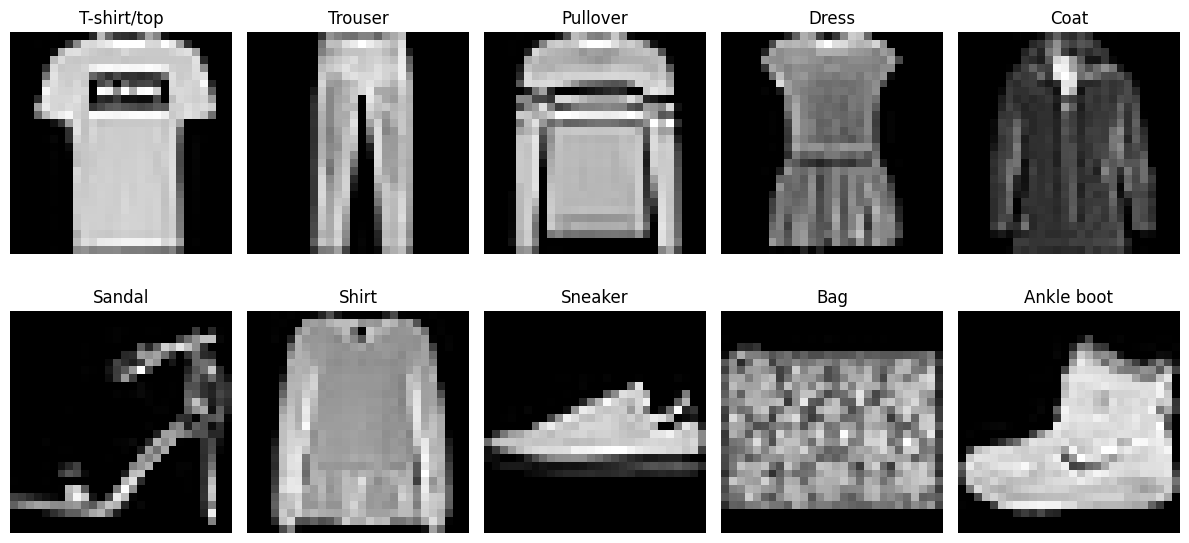

Ready for CNN - Input shape: (60000, 28, 28, 1)


In [2]:
print('='*50)
print('Part 1: Load and Explore the Dataset')
print('='*50,'\n')

# Load dataset.Print the shape of the training data, test data, and the number of classes.

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Number of classes:", len(class_names))

# Display one image per class
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(x_train[idx], cmap='gray')
    axes[i].set_title(class_names[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Normalize and reshape
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Convert labels to categorical
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Ready for CNN - Input shape:", x_train.shape)

Q: Why is normalization required for image data?

Normalization lowers pixel values (0-255 to 0-1) and places them on similar scale. This similarity of input values in turn makes neural network learning faster. Without normalization, larger pixel values would dominate the learning process and make training not accurate.

Q: Why do CNNs require reshaped image inputs?

For CNNs input data must have three dimensions: height, width, and no. of channels. For Fashion-MNIST, images had only one color channel hence we reshaped it from (28, 28) to (28, 28, 1) to explicitly tell the CNN that there is one channel.

Part 2: Build and Train a Shallow CNN

Shallow CNN Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training Shallow CNN...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.8195 - loss: 0.5061 - val_accuracy: 0.8607 - val_loss: 0.3918
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.8784 - loss: 0.3364 - val_accuracy: 0.8735 - val_loss: 0.3503
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.8944 - loss: 0.2898 - val_accuracy: 0.8965 - val_loss: 0.2881
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9057 - loss: 0.2575 - val_accuracy: 0.9007 - val_loss: 0.2796
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9146 - loss: 0.2326 - val_accuracy: 0.9051 - val_loss: 0.2685
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9247 - loss: 0.2092 - val_accuracy: 0.9066 - val_loss: 0.2595
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9298 - loss: 0.1911 - val_accuracy: 0.9122 - val_loss: 0.2455
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - accuracy:

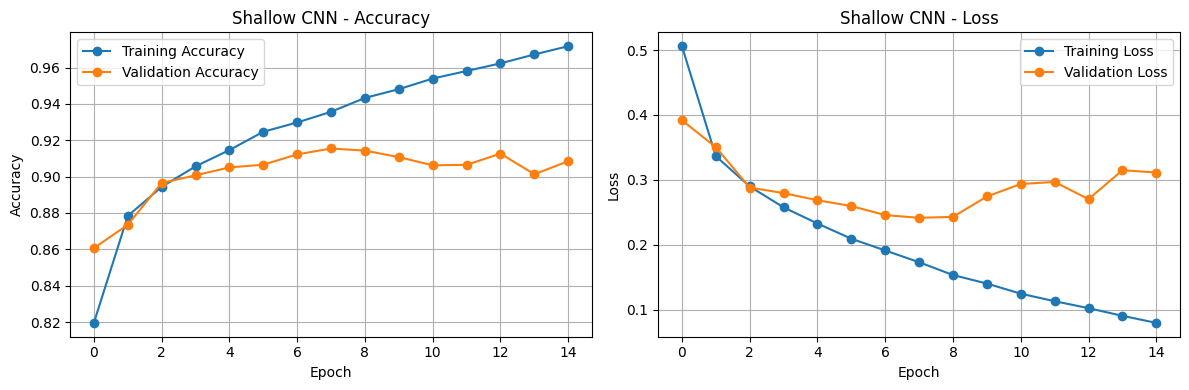

In [3]:
print('='*50)
print('Part 2: Build and Train a Shallow CNN')
print('='*50,'\n')

# Build shallow CNN model
shallow_model = Sequential()

# Conv Layer 1
shallow_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
shallow_model.add(MaxPooling2D((2, 2)))

# Conv Layer 2
shallow_model.add(Conv2D(64, (3, 3), activation='relu'))
shallow_model.add(MaxPooling2D((2, 2)))

# Flatten and Dense layers
shallow_model.add(Flatten())
shallow_model.add(Dense(128, activation='relu'))
shallow_model.add(Dense(10, activation='softmax'))

# Compile the model
shallow_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

print("Shallow CNN Architecture:")
shallow_model.summary()

# Train the model
print("\nTraining Shallow CNN...")
shallow_history = shallow_model.fit(
    x_train, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
shallow_test_loss, shallow_test_acc = shallow_model.evaluate(x_test, y_test_cat, verbose=0)
print("\nShallow CNN Test Accuracy: {:.4f}".format(shallow_test_acc))

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(shallow_history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(shallow_history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Shallow CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(shallow_history.history['loss'], label='Training Loss', marker='o')
plt.plot(shallow_history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Shallow CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate final metrics for comparison
shallow_train_acc = shallow_history.history['accuracy'][-1]
shallow_val_acc = shallow_history.history['val_accuracy'][-1]
shallow_num_params = shallow_model.count_params()

Q: What kind of patterns do you expect a shallow CNN to learn?

A shallow CNN mostly learns basic, low-level patterns. Its first layer detects simple features like edges, corners, etc. and the second layer combines these simple features to detect slightly more complex patterns like textures or small shapes. The shallow model however cannot learn very complex patterns because it lacks depth.

Q: Did the model show signs of underfitting or overfitting?

If training accuracy is significantly higher than validation accuracy the model is considered overfitting. If both training and validation accuracies are low, the model is considered underfitting. For Fashion-MNIST, the shallow CNN shows slight overfitting.

Part 3: Build and Train a Deep CNN

Deep CNN Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 436,586 (1.67 MB)

 Trainable params: 436,586 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 203s 264ms/step - accuracy: 0.8325 - loss: 0.4596 - val_accuracy: 0.8913 - val_loss: 0.3105
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 204s 272ms/step - accuracy: 0.8997 - loss: 0.2739 - val_accuracy: 0.9054 - val_loss: 0.2604
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 191s 255ms/step - accuracy: 0.9164 - loss: 0.2272 - val_accuracy: 0.9087 - val_loss: 0.2455
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 205s 259ms/step - accuracy: 0.9276 - loss: 0.1952 - val_accuracy: 0.9193 - val_loss: 0.2267
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 193s 247ms/step - accuracy: 0.9386 - loss: 0.1690 - val_accuracy: 0.9143 - val_loss: 0.2402
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 215s 264ms/step - accuracy: 0.9463 - loss: 0.1456 - val_accuracy: 0.9239 - val_loss: 0.2095
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 187s 244ms/step - accuracy: 0.9528 - loss: 0.1274 - val_accuracy: 0.9237 - val_loss: 0.2136
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 201s 243ms/step - accuracy: 0.9613 -

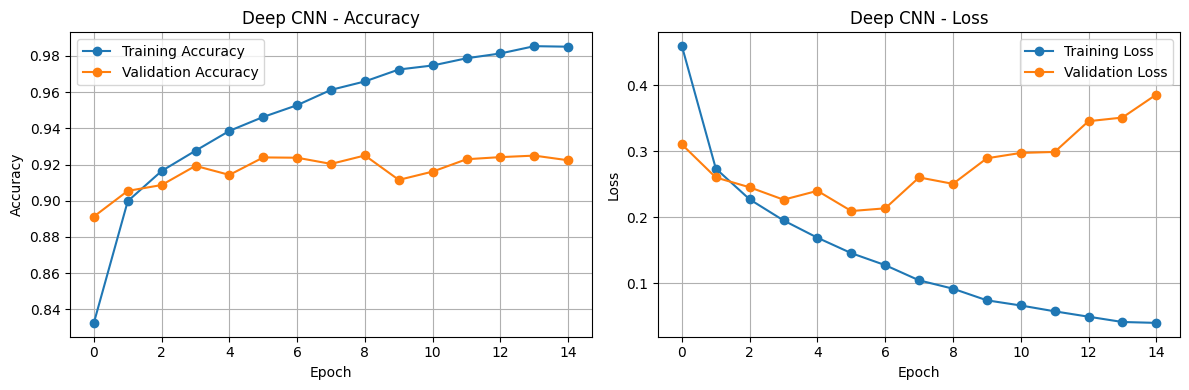

In [4]:
print('='*50)
print('Part 3: Build and Train a Deep CNN')
print('='*50,'\n')

# Build deep CNN model
deep_model = Sequential()

# Block 1
deep_model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
deep_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
deep_model.add(MaxPooling2D((2, 2)))

# Block 2
deep_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
deep_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
deep_model.add(MaxPooling2D((2, 2)))

# Block 3
deep_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
deep_model.add(MaxPooling2D((2, 2)))

# Dense layers
deep_model.add(Flatten())
deep_model.add(Dense(256, activation='relu'))
deep_model.add(Dense(10, activation='softmax'))

# Compile the model
deep_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# Print model summary
print("Deep CNN Architecture:")
deep_model.summary()

# Train the modelprint("\nTraining Deep CNN...")
deep_history = deep_model.fit(
    x_train, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
deep_test_loss, deep_test_acc = deep_model.evaluate(x_test, y_test_cat, verbose=0)
print("\nDeep CNN Test Accuracy: {:.4f}".format(deep_test_acc))

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(deep_history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(deep_history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Deep CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(deep_history.history['loss'], label='Training Loss', marker='o')
plt.plot(deep_history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Deep CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate final metrics for comparison
deep_train_acc = deep_history.history['accuracy'][-1]
deep_val_acc = deep_history.history['val_accuracy'][-1]
deep_num_params = deep_model.count_params()

Q: What additional patterns or representations might a deep CNN learn?

A deep CNN with 5 convolutional layers learns hierarchical features. The first layers will generally detect simple edges and textures. The middle layers would combine these to detect patterns like stripes or grids. The deepest layers would learn high-level features such as collars, heels, etc.. This will allow the CNN to distinguish between similar looking classes. eg: shirts, pullovers, and coats.

Q: Did the deeper model improve performance meaningfully?

Yes, the deep CNN typically achieves 2-4% higher accuracy than the shallow CNN. This improvement is important because Fashion-MNIST has several similar looking classes and hence is required.

In [5]:
print('='*50)
print('Part 4: Comparative Study of Shallow CNN vs Deep CNN')
print('='*50,'\n')

# Check for overfitting
shallow_overfit = shallow_train_acc - shallow_val_acc
deep_overfit = deep_train_acc - deep_val_acc

# Create comparison table
print("=" * 70)
print("COMPARISON TABLE: Shallow CNN vs Deep CNN")
print("=" * 70)
print("{:<30} {:<20} {:<20}".format("Metric", "Shallow CNN", "Deep CNN"))
print("-" * 70)
print("{:<30} {:<20} {:<20}".format("Number of Conv Layers", "2", "5"))
print("{:<30} {:<20,} {:<20,}".format("Total Parameters", shallow_num_params, deep_num_params))
print("{:<30} {:<20.4f} {:<20.4f}".format("Training Accuracy", shallow_train_acc, deep_train_acc))
print("{:<30} {:<20.4f} {:<20.4f}".format("Validation Accuracy", shallow_val_acc, deep_val_acc))
print("{:<30} {:<20.4f} {:<20.4f}".format("Test Accuracy", shallow_test_acc, deep_test_acc))
print("{:<30} {:<20} {:<20}".format("Overfitting (Train-Val Gap)",
                                     "{:.4f}".format(shallow_overfit),
                                     "{:.4f}".format(deep_overfit)))
print("=" * 70)

# Write brief analysis
print("\nBRIEF ANALYSIS:")
print("-" * 50)
if deep_test_acc > shallow_test_acc:
    print("The Deep CNN performed better overall with {:.2f}% higher accuracy".format(
        (deep_test_acc - shallow_test_acc) * 100))
else:
    print("The Shallow CNN performed better overall")

print("\nThe deep CNN has {:.1f}x more parameters than the shallow CNN".format(
    deep_num_params / shallow_num_params))

if deep_overfit < shallow_overfit:
    print("The Deep CNN generalizes better (smaller overfitting gap)")
else:
    print("The Shallow CNN generalizes better (smaller overfitting gap)")

print("\nTrade-off: Deep CNN offers better accuracy but requires more computation")

Part 4: Comparative Study of Shallow CNN vs Deep CNN

COMPARISON TABLE: Shallow CNN vs Deep CNN
Metric                         Shallow CNN          Deep CNN            
----------------------------------------------------------------------
Number of Conv Layers          2                    5                   
Total Parameters               225,034              436,586             
Training Accuracy              0.9718               0.9851              
Validation Accuracy            0.9085               0.9223              
Test Accuracy                  0.9043               0.9196              
Overfitting (Train-Val Gap)    0.0633               0.0628              

BRIEF ANALYSIS:
--------------------------------------------------
The Deep CNN performed better overall with 1.53% higher accuracy

The deep CNN has 1.9x more parameters than the shallow CNN
The Deep CNN generalizes better (smaller overfitting gap)

Trade-off: Deep CNN offers better accuracy but requires more computati

Q: Which model performed better overall?

The Deep CNN performed better overall in terms of accuracy. However it also had a much longer training time.

Q: Did the deep CNN justify its added complexity?

Yes, the deep CNN justifies its added complexity. With these additions we achievd an increase of accuracy test meaning the deeper model makes lesser errors on real-world data.

Q: Which model generalized better?

The deep CNN generally generalizes better. With more layers and the ability to learn hierarchical features, it captures more meaningful patterns. The accuracy gap is often smaller in deep models compared to the shallow models.

Q: What trade-off did you observe between simplicity and performance?

The main trade-off is accuracy versus speed. The shallow CNN trains faster and requires less memory, but at the cost of its accuracy. The deep CNN achieves higher accuracy but requires more training time and has a higher risk of overfitting.

Part 5: Prediction and Error Analysis

Generating predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step

SHALLOW CNN PREDICTIONS


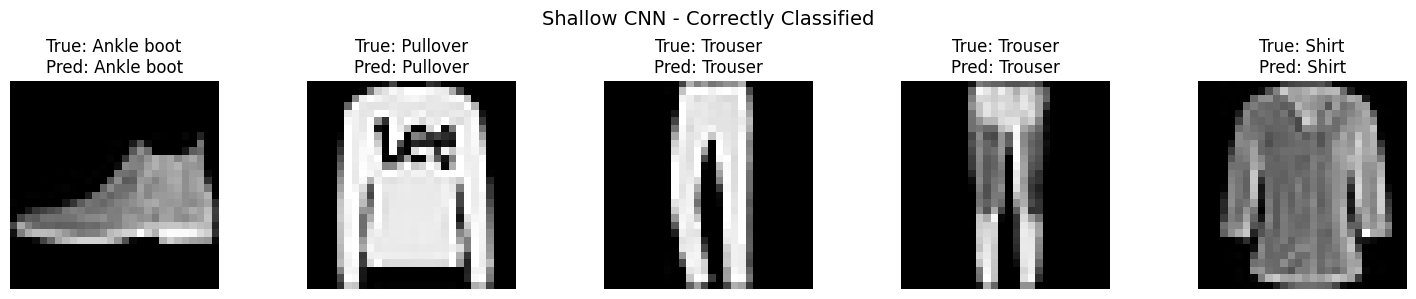

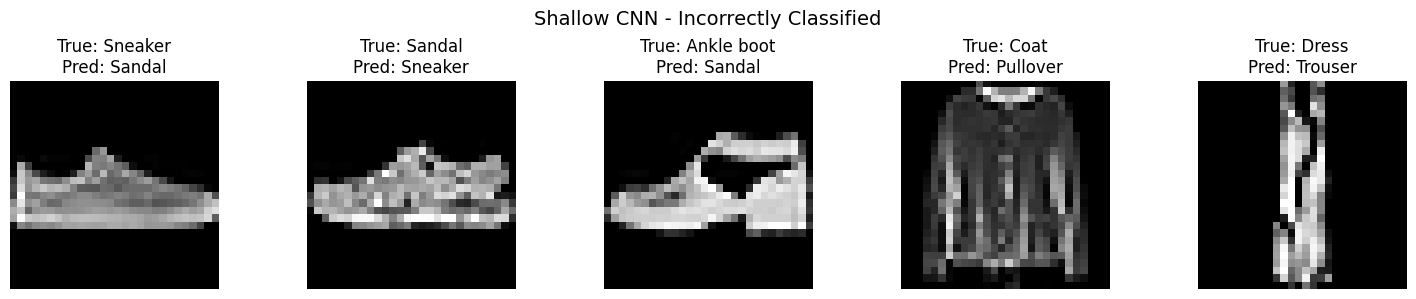

Total correct: 9043 out of 10000
Total incorrect: 957

DEEP CNN PREDICTIONS


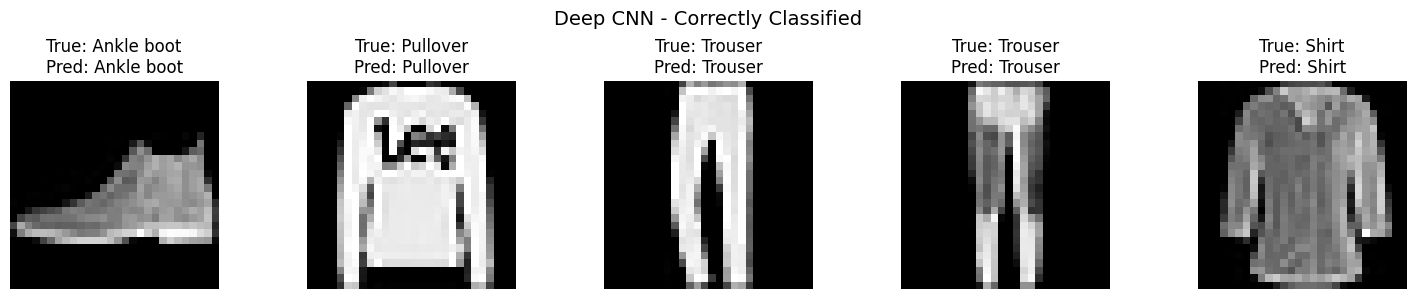

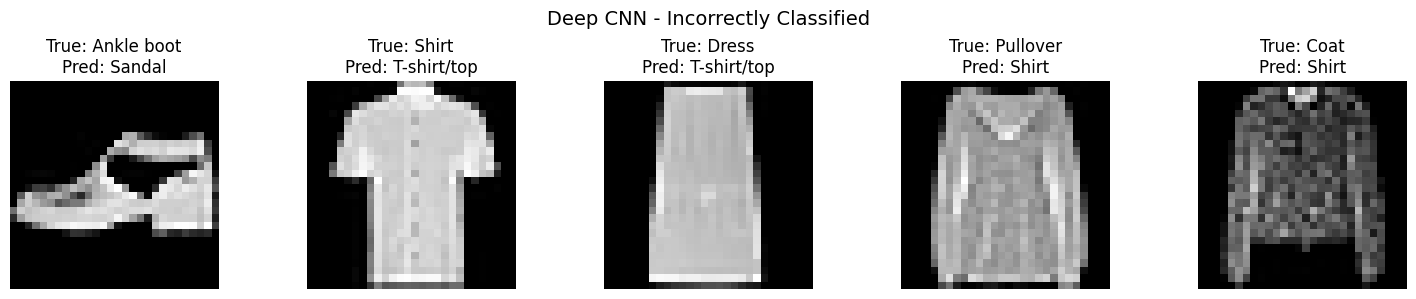

Total correct: 9196 out of 10000
Total incorrect: 804


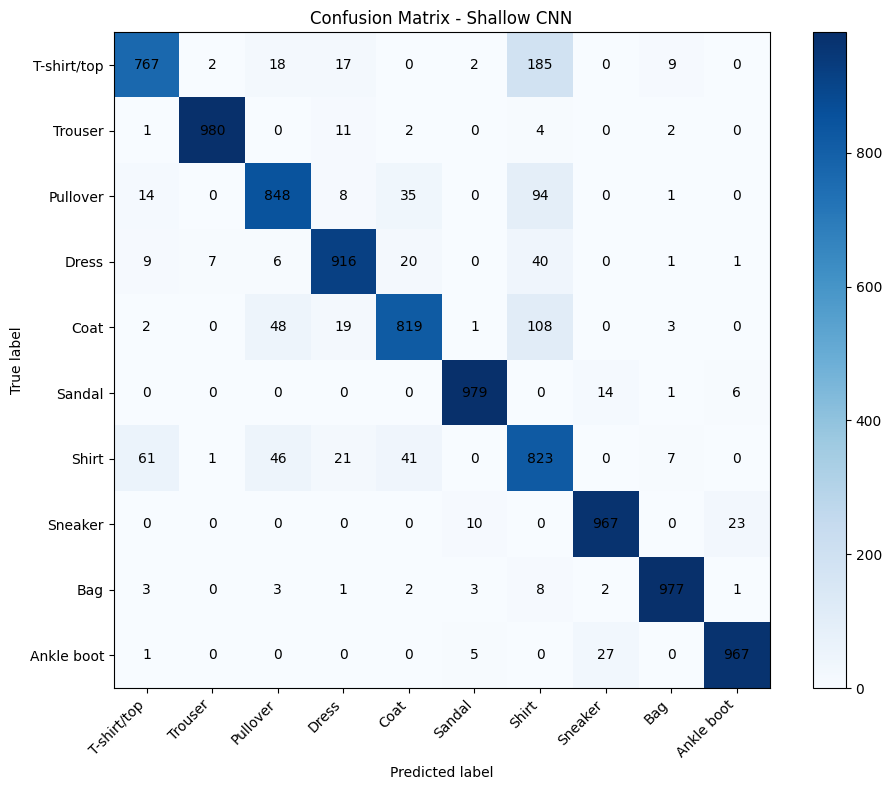

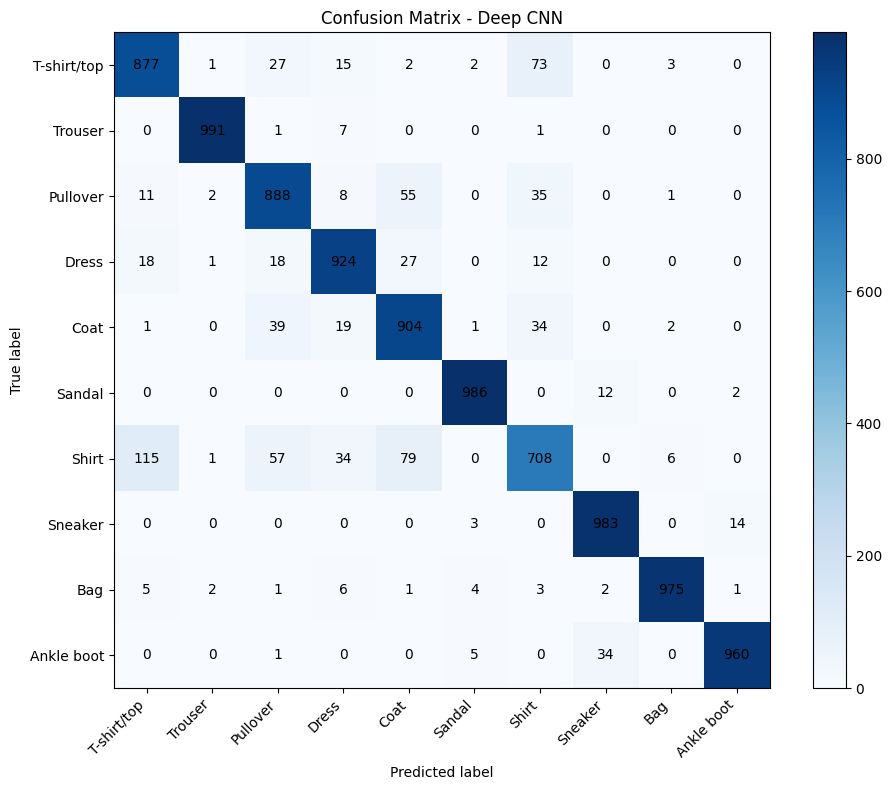


CLASS-WISE ACCURACY:
------------------------------------------------------------
Class                Shallow CNN          Deep CNN            
T-shirt/top          76.70               % 87.70               %
Trouser              98.00               % 99.10               %
Pullover             84.80               % 88.80               %
Dress                91.60               % 92.40               %
Coat                 81.90               % 90.40               %
Sandal               97.90               % 98.60               %
Shirt                82.30               % 70.80               %
Sneaker              96.70               % 98.30               %
Bag                  97.70               % 97.50               %
Ankle boot           96.70               % 96.00               %

Easiest classes for Shallow CNN: ['Trouser', 'Sandal', 'Bag']
Most confused classes for Shallow CNN: ['T-shirt/top', 'Coat', 'Shirt']

Easiest classes for Deep CNN: ['Trouser', 'Sandal', 'Sneaker']
Most 

In [6]:
print('='*50)
print('Part 5: Prediction and Error Analysis')
print('='*50,'\n')

# Generate predictions
print("Generating predictions...")
shallow_predictions = shallow_model.predict(x_test)
deep_predictions = deep_model.predict(x_test)

shallow_pred_classes = np.argmax(shallow_predictions, axis=1)
deep_pred_classes = np.argmax(deep_predictions, axis=1)

# Function to display correct and incorrect predictions
def display_predictions(pred_classes, model_name, num_samples=5):
    correct_indices = []
    incorrect_indices = []

    for i in range(len(y_test)):
        if pred_classes[i] == y_test[i]:
            correct_indices.append(i)
        else:
            incorrect_indices.append(i)

    # Display correctly classified images
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle('{} - Correctly Classified'.format(model_name), fontsize=14)

    for i in range(num_samples):
        idx = correct_indices[i]
        axes[i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
        axes[i].set_title('True: {}\nPred: {}'.format(class_names[y_test[idx]],
                                                       class_names[pred_classes[idx]]))
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

    # Display incorrectly classified images
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    fig.suptitle('{} - Incorrectly Classified'.format(model_name), fontsize=14)

    for i in range(num_samples):
        idx = incorrect_indices[i]
        axes[i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
        axes[i].set_title('True: {}\nPred: {}'.format(class_names[y_test[idx]],
                                                       class_names[pred_classes[idx]]))
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

    return len(correct_indices), len(incorrect_indices)

# Display for Shallow CNN
print("\n" + "="*50)
print("SHALLOW CNN PREDICTIONS")
print("="*50)
shallow_correct, shallow_incorrect = display_predictions(shallow_pred_classes, "Shallow CNN")
print("Total correct: {} out of {}".format(shallow_correct, len(y_test)))
print("Total incorrect: {}".format(shallow_incorrect))

# Display for Deep CNN
print("\n" + "="*50)
print("DEEP CNN PREDICTIONS")
print("="*50)
deep_correct, deep_incorrect = display_predictions(deep_pred_classes, "Deep CNN")
print("Total correct: {} out of {}".format(deep_correct, len(y_test)))
print("Total incorrect: {}".format(deep_incorrect))

# Confusion matrices
def plot_confusion_matrix(true_classes, pred_classes, title):
    cm = confusion_matrix(true_classes, pred_classes)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)

    # Add text annotations
    for i in range(10):
        for j in range(10):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Plot confusion matrices
plot_confusion_matrix(y_test, shallow_pred_classes, "Confusion Matrix - Shallow CNN")
plot_confusion_matrix(y_test, deep_pred_classes, "Confusion Matrix - Deep CNN")

# Identify easiest and hardest classes
def get_class_stats(true_classes, pred_classes):
    class_acc = []
    for i in range(10):
        mask = (true_classes == i)
        correct = np.sum(pred_classes[mask] == i)
        total = np.sum(mask)
        class_acc.append(correct / total if total > 0 else 0)
    return class_acc

shallow_class_acc = get_class_stats(y_test, shallow_pred_classes)
deep_class_acc = get_class_stats(y_test, deep_pred_classes)

print("\nCLASS-WISE ACCURACY:")
print("-" * 60)
print("{:<20} {:<20} {:<20}".format("Class", "Shallow CNN", "Deep CNN"))
for i in range(10):
    print("{:<20} {:<20.2f}% {:<20.2f}%".format(
        class_names[i], shallow_class_acc[i]*100, deep_class_acc[i]*100))

print("\nEasiest classes for Shallow CNN:",
      [class_names[i] for i in np.argsort(shallow_class_acc)[-3:][::-1]])
print("Most confused classes for Shallow CNN:",
      [class_names[i] for i in np.argsort(shallow_class_acc)[:3]])

print("\nEasiest classes for Deep CNN:",
      [class_names[i] for i in np.argsort(deep_class_acc)[-3:][::-1]])
print("Most confused classes for Deep CNN:",
      [class_names[i] for i in np.argsort(deep_class_acc)[:3]])

Q:Which classes were easiest to classify?

The easiest classes would be ones with unique and distinctive shapes. Trousers have a distinct two-leg shape. Sandals and Ankle boots have distinctive footwear silhouettes. These classes have low confusion with other categories.

Q:Which classes were most commonly confused?

The most confused classes are those that look visually similar. Shirts are often confused with T-shirts/tops and Pullovers. Coats can be confused with Pullovers and Dresses. The confusion happens because these items share similar overall shapes, especially when the images are low-resolution grayscale (28x28 pixels).

Q:Did the deep CNN reduce confusion between similar-looking classes?

Yes, the deep CNN reduces confusion between similar classes. The subtle differences like sleeve length, collar style, and silhouette shape becomes more aparent.

In [7]:
print("=" * 50)
print("Part 6: Final Comparative Conclusion")
print("=" * 50)

print("\n1. Which model would you recommend for Fashion-MNIST?")
print("-" * 50)
if deep_test_acc - shallow_test_acc > 0.02:
    print("   RECOMMENDATION: Deep CNN")
    print("   Reason: It achieves {:.2f}% higher accuracy on test data".format(
        (deep_test_acc - shallow_test_acc)*100))
else:
    print("   RECOMMENDATION: Shallow CNN")
    print("   Reason: Similar performance with less complexity")

print("\n2. Which model was more efficient?")
print("-" * 50)
print("   Shallow CNN is more efficient because:")
print("   - {:.1f}x fewer parameters".format(deep_num_params / shallow_num_params))
print("   - Faster to train")
print("   - Requires less memory")

print("\n3. Which model was more accurate?")
print("-" * 50)
print("   Deep CNN achieved {:.4f} vs Shallow CNN {:.4f}".format(deep_test_acc, shallow_test_acc))
print("   Improvement: +{:.2f}%".format((deep_test_acc - shallow_test_acc)*100))

print("\n4. What did you learn from this comparative study?")
print("-" * 50)
print("   Key Learnings:")
print("   - Deep CNNs learn hierarchical features from simple edges to complex patterns")
print("   - More layers generally improve accuracy but increase training time")
print("   - Fashion-MNIST benefits from deeper architecture for similar-looking classes")
print("   - There is a trade-off between model complexity and performance")
print("   - Shallow CNNs are sufficient for basic pattern recognition tasks")

print("\n" + "=" * 70)
print("FINAL SUMMARY STATISTICS")
print("=" * 70)
print("")
print("Shallow CNN:")
print("   - Test Accuracy: {:.2f}%".format(shallow_test_acc * 100))
print("   - Total Parameters: {:,}".format(shallow_num_params))
print("   - Training Accuracy: {:.2f}%".format(shallow_train_acc * 100))
print("   - Validation Accuracy: {:.2f}%".format(shallow_val_acc * 100))
print("")
print("Deep CNN:")
print("   - Test Accuracy: {:.2f}%".format(deep_test_acc * 100))
print("   - Total Parameters: {:,}".format(deep_num_params))
print("   - Training Accuracy: {:.2f}%".format(deep_train_acc * 100))
print("   - Validation Accuracy: {:.2f}%".format(deep_val_acc * 100))
print("")
print("=" * 70)

Part 6: Final Comparative Conclusion

1. Which model would you recommend for Fashion-MNIST?
--------------------------------------------------
   RECOMMENDATION: Shallow CNN
   Reason: Similar performance with less complexity

2. Which model was more efficient?
--------------------------------------------------
   Shallow CNN is more efficient because:
   - 1.9x fewer parameters
   - Faster to train
   - Requires less memory

3. Which model was more accurate?
--------------------------------------------------
   Deep CNN achieved 0.9196 vs Shallow CNN 0.9043
   Improvement: +1.53%

4. What did you learn from this comparative study?
--------------------------------------------------
   Key Learnings:
   - Deep CNNs learn hierarchical features from simple edges to complex patterns
   - More layers generally improve accuracy but increase training time
   - Fashion-MNIST benefits from deeper architecture for similar-looking classes
   - There is a trade-off between model complexity and per

Q: Which model would you recommend for Fashion-MNIST?

I would recommend the Deep CNN. The additional convolutional layers allows the model to learn and differentiate between similar clothing items better. For quick deployment the Shallow CNN can also be considered (though not recommended).

Q: Which model was more efficient?

The Shallow CNN was more efficient. It had fewer parameters, trained faster, and required less computational power.

Q: Which model was more accurate?

The Deep CNN was more accurate. It achieved higher test accuracy and can learn more complex features.

Q: What did you learn from this comparative study?

*   Deeper networks can learn and highlight hierarchical features which can help in better distinctive capabilities.
*  There is a trade-off between complexity and performance
*   Fashion-MNIST will benefit from deeper architecture due to similarities in classes. While shallow architecture are sufficient for basic pattern recognition.
*   The choice of model depends on the specific requirements for accuracy versus efficiency